In [12]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from wrf_io import *
from scipy.io import savemat
from MITRotor import IEA10MW
from itertools import product
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler

## Train data

In [3]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'

In [4]:
casenames = [
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200'
]

In [5]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/parameters.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [22]:
fontsize = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [23]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_pow_full_uvw      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_full_uvw      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    # v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,w_rotor)

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_thr_full_uvw[count]   = T
    wrf_pow_full_uvw[count]   = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

# END LOOP

In [24]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_pow_full_uv      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_full_uv      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    # v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_thr_full_uv[count]   = T
    wrf_pow_full_uv[count]   = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

# END LOOP

In [25]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_pow_uvinf      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_uvinf      = np.zeros(len(casenames),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf.T

    v_rotor = v_inf.T

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_thr_uvinf[count]   = T
    wrf_pow_uvinf[count]   = P

# END LOOP

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

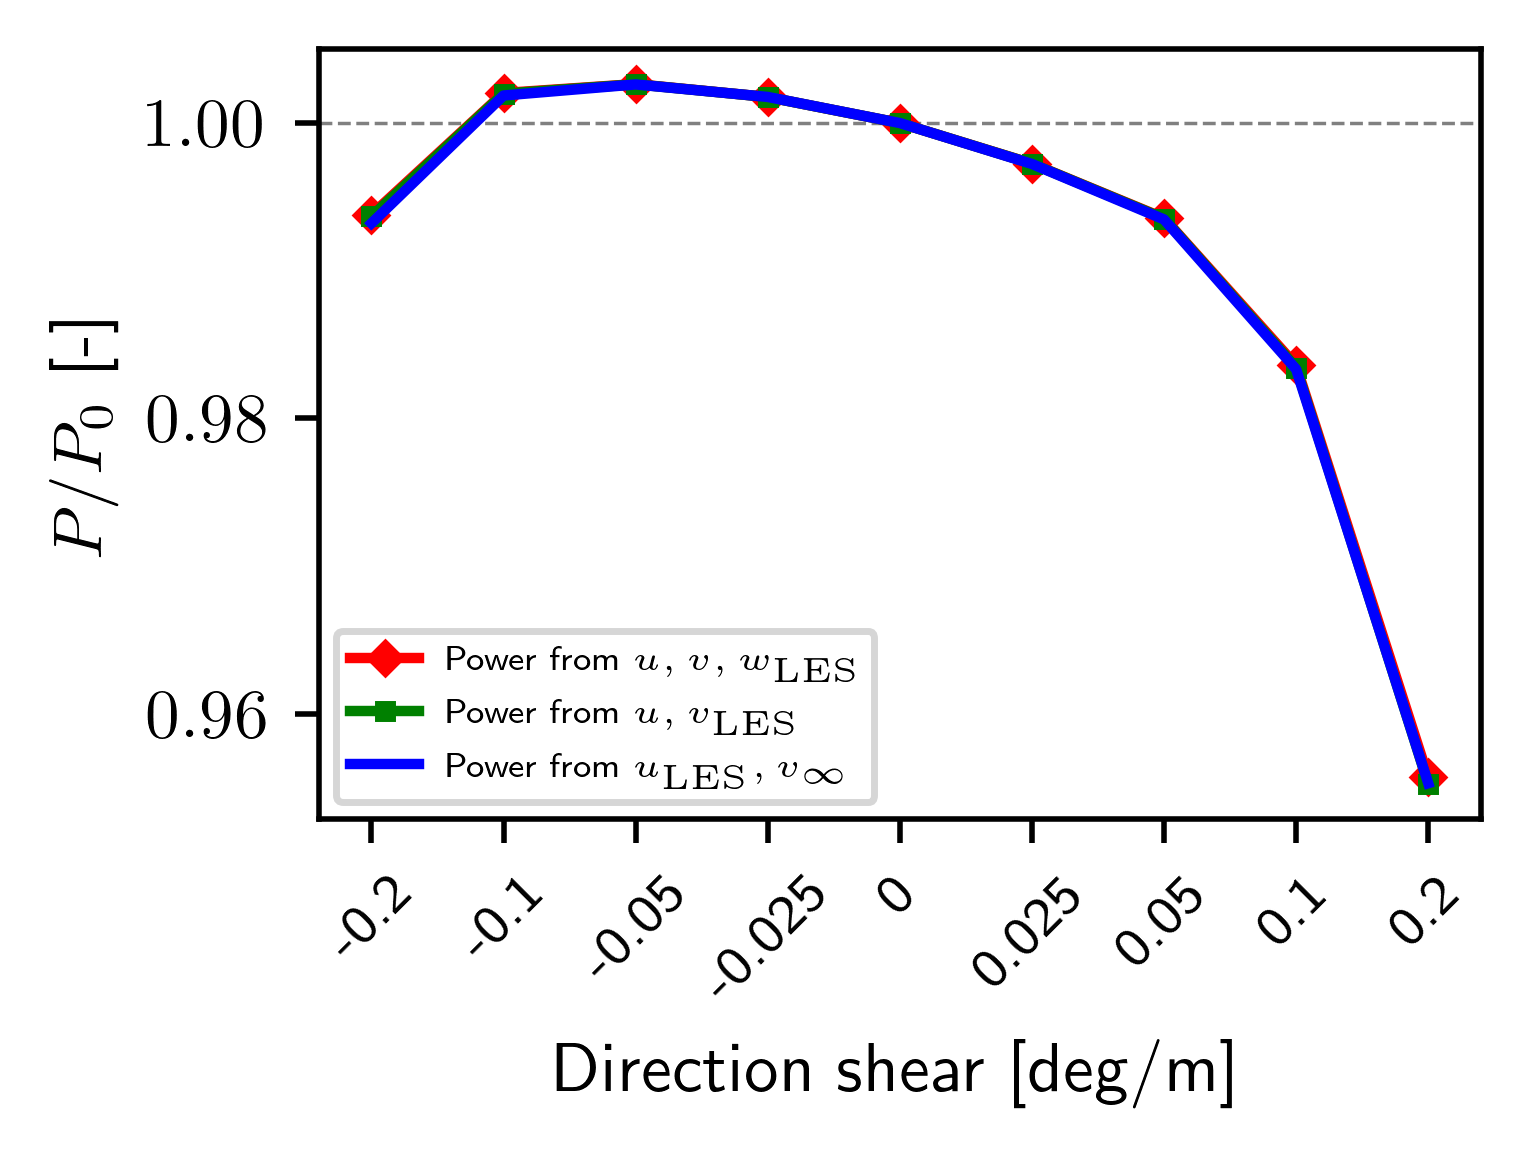

In [26]:
fig, ax = plt.subplots(figsize=(3, 2))

ref_ind = 4

ax.plot(wrf_pow_real/wrf_pow_real[ref_ind], marker='D', markersize=3, color='r', zorder=2, label='Power from $u,v,w_{\\textrm{LES}}$')
ax.plot(wrf_pow_full_uv/wrf_pow_full_uv[ref_ind], marker = 's', markersize=2, color='g', zorder=2, label='Power from $u,v_{\\textrm{LES}}$')
ax.plot(wrf_pow_uvinf/wrf_pow_uvinf[ref_ind], color='b', zorder=2,  label='Power from $u_{\\textrm{LES}}, v_{\infty}$')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5,zorder=1)

ax.legend(fontsize=5)

ax.set_ylabel('$P/P_0$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

# ax.set_yscale('log')

In [27]:
full_uvw_err = postproc.per_error(wrf_pow_full_uvw, wrf_pow_real)
full_uv_err = postproc.per_error(wrf_pow_full_uv, wrf_pow_real)
uvinf_err = postproc.per_error(wrf_pow_uvinf, wrf_pow_real)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

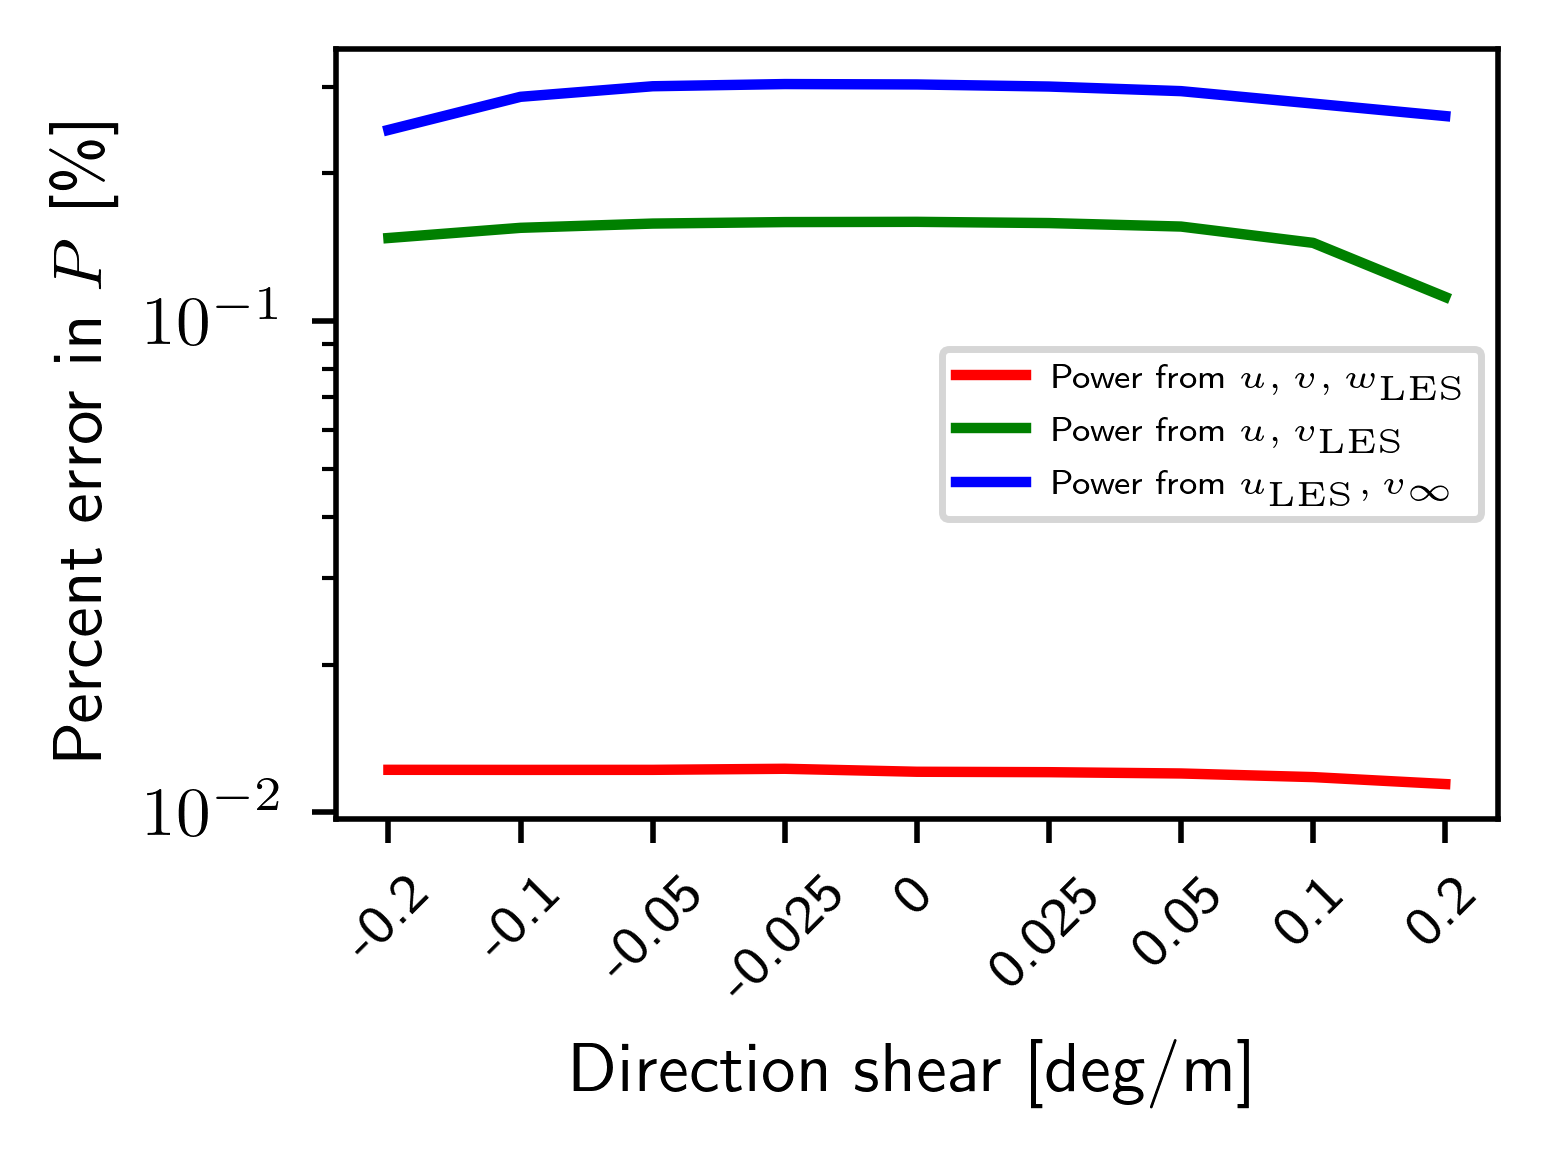

In [28]:
fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(full_uvw_err, color='r', label='Power from $u,v,w_{\\textrm{LES}}$')
ax.plot(full_uv_err, color='g', label='Power from $u,v_{\\textrm{LES}}$')
ax.plot(uvinf_err, color='b', label='Power from $u_{\\textrm{LES}}, v_{\infty}$')
ax.legend(fontsize=5)

ax.set_ylabel('Percent error in $P$ [\%]')
ax.set_xlabel('Direction shear [deg/m]')

ax.set_yscale('log')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)